In [2]:
import pandas as pd
df=pd.read_csv("../data/wheat_mandi_data.csv")
df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [3]:
# Filter only Rajasthan and Wheat
df_filtered = df[(df["STATE"] == "Rajasthan") & (df["Commodity"] == "Wheat")]

df_filtered.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
11,Rajasthan,pratapgarh,Pratapgarh,Wheat,Dara,FAQ,2250.0,2450.0,2300.0,6/6/2023
88,Rajasthan,tonk,Dooni,Wheat,147 Average,FAQ,2120.0,2140.0,2130.0,6/6/2023
135,Rajasthan,chittorgarh,Kapasan,Wheat,Lokwan,FAQ,2050.0,2250.0,2150.0,6/6/2023
209,Rajasthan,bikaner,Lunkaransar,Wheat,Other,FAQ,2080.0,2350.0,2160.0,6/6/2023


In [4]:
df_filtered["Price Date"] = pd.to_datetime(df_filtered["Price Date"])

df_filtered = df_filtered.sort_values("Price Date")

df_filtered.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,2023-06-06
856,Rajasthan,kota,Ramganjmandi,Wheat,Other,FAQ,2150.0,2269.0,2212.0,2023-06-06
864,Rajasthan,bikaner,Sridungargarh,Wheat,Other,FAQ,2200.0,2661.0,2571.0,2023-06-06
911,Rajasthan,jhalawar,Khanpur,Wheat,Other,FAQ,2150.0,2426.0,2250.0,2023-06-06
929,Rajasthan,udaipur,Fatehnagar,Wheat,Local,FAQ,2185.0,2241.0,2224.0,2023-06-06


In [5]:
df_filtered = df_filtered[["Price Date", "Modal_Price"]]

df_filtered.head()


,Price Date,Modal_Price
3,2023-06-06,2300.0
856,2023-06-06,2212.0
864,2023-06-06,2571.0
911,2023-06-06,2250.0
929,2023-06-06,2224.0


In [6]:
len(df_filtered)

8447

In [7]:
# Group by date and calculate average modal price
df_daily = df_filtered.groupby("Price Date")["Modal_Price"].mean().reset_index()

df_daily.head()

,Price Date,Modal_Price
0,2023-06-06,2211.395349
1,2023-06-07,2214.188679
2,2023-06-08,2201.107143
3,2023-06-09,2190.396552
4,2023-06-10,2199.111111


In [8]:
len(df_daily)


245

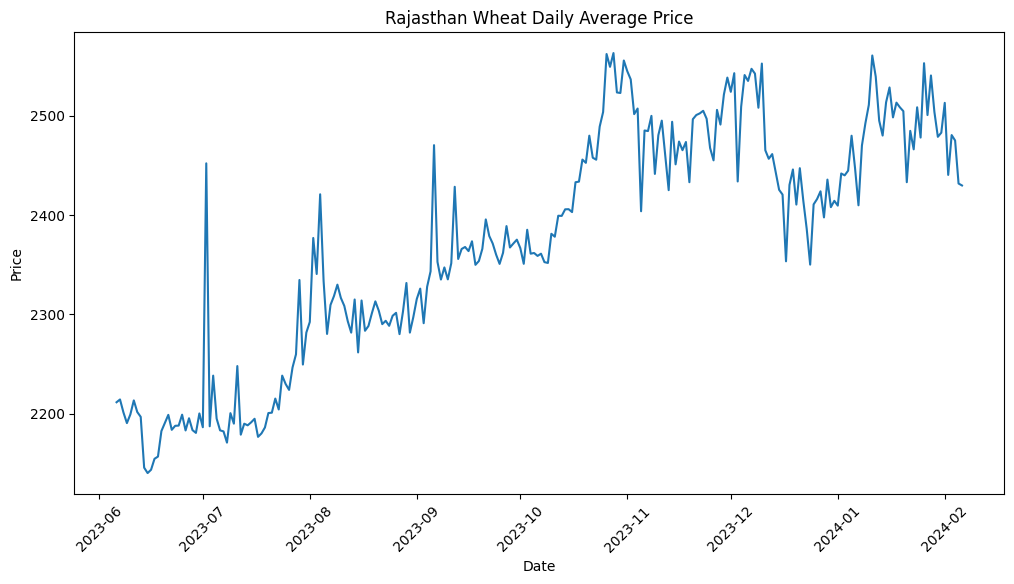

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_daily["Price Date"], df_daily["Modal_Price"])
plt.title("Rajasthan Wheat Daily Average Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

In [10]:
import numpy as np

overall_volatility = np.std(df_daily["Modal_Price"])

print("Overall Price Volatility (Std Dev):", overall_volatility)

Overall Price Volatility (Std Dev): 117.44922174207287


In [11]:
df_daily["rolling_volatility"] = df_daily["Modal_Price"].rolling(window=30).std()

df_daily.head()


,Price Date,Modal_Price,rolling_volatility
0,2023-06-06,2211.395349,NaN
1,2023-06-07,2214.188679,NaN
2,2023-06-08,2201.107143,NaN
3,2023-06-09,2190.396552,NaN
4,2023-06-10,2199.111111,NaN


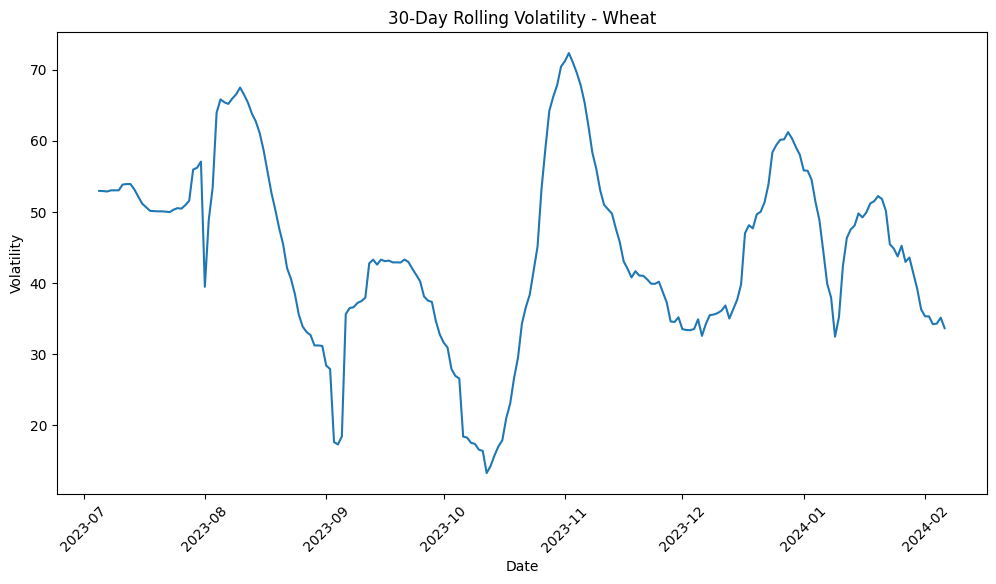

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df_daily["Price Date"], df_daily["rolling_volatility"])
plt.title("30-Day Rolling Volatility - Wheat")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()

In [13]:
mean_price = df_daily["Modal_Price"].mean()

print("Mean Price:", mean_price)

Mean Price: 2372.648309951488


In [14]:
overall_volatility = np.std(df_daily["Modal_Price"])

risk_score = overall_volatility / mean_price

print("Overall Volatility:", overall_volatility)
print("Risk Score:", risk_score)

Overall Volatility: 117.44922174207287
Risk Score: 0.04950131936935663


In [15]:
#This makes risk time-dependent.
df_daily["dynamic_risk_score"] = df_daily["rolling_volatility"] / mean_price

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score
240,2024-02-02,2440.350000,35.279318,0.014869
241,2024-02-03,2480.473684,34.188629,0.014409
242,2024-02-04,2475.000000,34.267796,0.014443
243,2024-02-05,2431.685714,35.104140,0.014795
244,2024-02-06,2429.700000,33.627884,0.014173


In [16]:
def classify_dynamic_risk(score):
    if score < 0.02:
        return "Low"
    elif score < 0.04:
        return "Medium"
    else:
        return "High"

df_daily["risk_category"] = df_daily["dynamic_risk_score"].apply(classify_dynamic_risk)

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score,risk_category
240,2024-02-02,2440.350000,35.279318,0.014869,Low
241,2024-02-03,2480.473684,34.188629,0.014409,Low
242,2024-02-04,2475.000000,34.267796,0.014443,Low
243,2024-02-05,2431.685714,35.104140,0.014795,Low
244,2024-02-06,2429.700000,33.627884,0.014173,Low


In [17]:
def selling_advice(risk):
    if risk == "Low":
        return "Hold"
    elif risk == "Medium":
        return "Monitor"
    else:
        return "Consider Selling"

df_daily["advice"] = df_daily["risk_category"].apply(selling_advice)

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score,risk_category,advice
240,2024-02-02,2440.350000,35.279318,0.014869,Low,Hold
241,2024-02-03,2480.473684,34.188629,0.014409,Low,Hold
242,2024-02-04,2475.000000,34.267796,0.014443,Low,Hold
243,2024-02-05,2431.685714,35.104140,0.014795,Low,Hold
244,2024-02-06,2429.700000,33.627884,0.014173,Low,Hold


In [18]:
df_daily["price_change_7d"] = df_daily["Modal_Price"].diff(7)

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score,risk_category,advice,price_change_7d
240,2024-02-02,2440.350000,35.279318,0.014869,Low,Hold,-112.507143
241,2024-02-03,2480.473684,34.188629,0.014409,Low,Hold,-20.162679
242,2024-02-04,2475.000000,34.267796,0.014443,Low,Hold,-65.500000
243,2024-02-05,2431.685714,35.104140,0.014795,Low,Hold,-72.119164
244,2024-02-06,2429.700000,33.627884,0.014173,Low,Hold,-49.014286


In [19]:
def trend_direction(change):
    if change > 0:
        return "Up"
    elif change < 0:
        return "Down"
    else:
        return "Stable"

df_daily["trend"] = df_daily["price_change_7d"].apply(trend_direction)

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score,risk_category,advice,price_change_7d,trend
240,2024-02-02,2440.350000,35.279318,0.014869,Low,Hold,-112.507143,Down
241,2024-02-03,2480.473684,34.188629,0.014409,Low,Hold,-20.162679,Down
242,2024-02-04,2475.000000,34.267796,0.014443,Low,Hold,-65.500000,Down
243,2024-02-05,2431.685714,35.104140,0.014795,Low,Hold,-72.119164,Down
244,2024-02-06,2429.700000,33.627884,0.014173,Low,Hold,-49.014286,Down


In [20]:
def smart_advice(row):
    risk = row["risk_category"]
    trend = row["trend"]
    
    if risk == "Low" and trend == "Up":
        return "Hold"
    elif risk == "Low" and trend == "Down":
        return "Monitor"
    elif risk == "High" and trend == "Down":
        return "Sell"
    elif risk == "High" and trend == "Up":
        return "Cautious Hold"
    else:
        return "Monitor"

df_daily["smart_advice"] = df_daily.apply(smart_advice, axis=1)

df_daily.tail()

,Price Date,Modal_Price,rolling_volatility,dynamic_risk_score,risk_category,advice,price_change_7d,trend,smart_advice
240,2024-02-02,2440.350000,35.279318,0.014869,Low,Hold,-112.507143,Down,Monitor
241,2024-02-03,2480.473684,34.188629,0.014409,Low,Hold,-20.162679,Down,Monitor
242,2024-02-04,2475.000000,34.267796,0.014443,Low,Hold,-65.500000,Down,Monitor
243,2024-02-05,2431.685714,35.104140,0.014795,Low,Hold,-72.119164,Down,Monitor
244,2024-02-06,2429.700000,33.627884,0.014173,Low,Hold,-49.014286,Down,Monitor


In [21]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = df_daily[["Price Date", "Modal_Price"]].copy()

prophet_df = prophet_df.rename(columns={
    "Price Date": "ds",
    "Modal_Price": "y"
})

prophet_df.head()

,ds,y
0,2023-06-06,2211.395349
1,2023-06-07,2214.188679
2,2023-06-08,2201.107143
3,2023-06-09,2190.396552
4,2023-06-10,2199.111111


In [22]:
model = Prophet()

model.fit(prophet_df)


12:58:57 - cmdstanpy - INFO - Chain [1] start processing
12:58:58 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = model.make_future_dataframe(periods=30)

future.tail()

,ds
270,2024-03-03
271,2024-03-04
272,2024-03-05
273,2024-03-06
274,2024-03-07


In [24]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-06-06,2166.354287,2113.487795,2226.786601,2166.354287,2166.354287,5.322914,5.322914,5.322914,5.322914,5.322914,5.322914,0.0,0.0,0.0,2171.677201
1,2023-06-07,2167.928982,2120.013869,2229.110543,2167.928982,2167.928982,6.251742,6.251742,6.251742,6.251742,6.251742,6.251742,0.0,0.0,0.0,2174.180723
2,2023-06-08,2169.503677,2120.830118,2231.062427,2169.503677,2169.503677,4.453948,4.453948,4.453948,4.453948,4.453948,4.453948,0.0,0.0,0.0,2173.957625
3,2023-06-09,2171.078371,2120.123184,2226.004075,2171.078371,2171.078371,4.643362,4.643362,4.643362,4.643362,4.643362,4.643362,0.0,0.0,0.0,2175.721733
4,2023-06-10,2172.653066,2118.095875,2227.951926,2172.653066,2172.653066,0.337186,0.337186,0.337186,0.337186,0.337186,0.337186,0.0,0.0,0.0,2172.990252


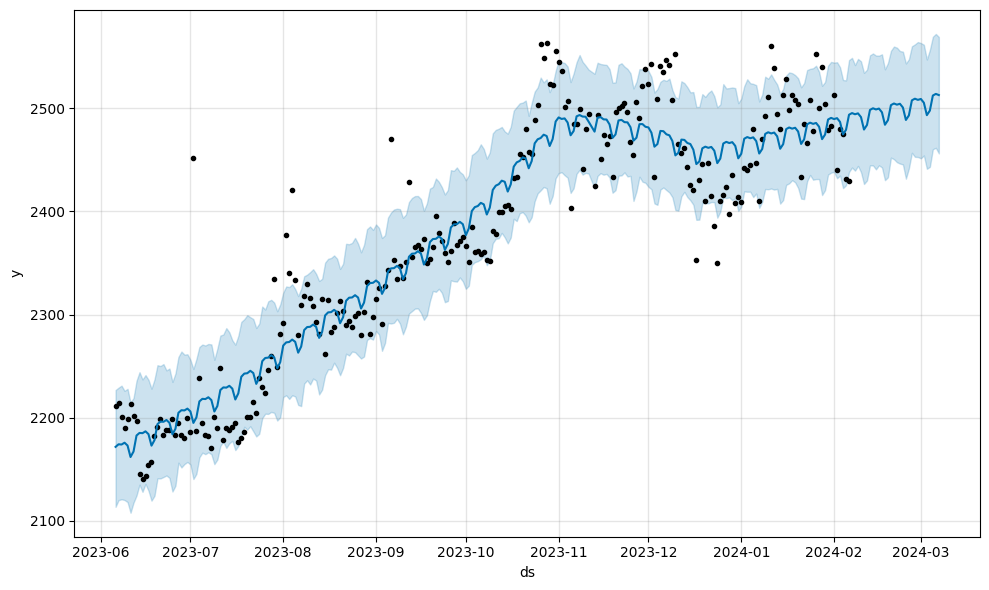

In [25]:
fig1 = model.plot(forecast)

In [26]:
future_forecast = forecast.tail(30)[["ds", "yhat", "yhat_lower", "yhat_upper"]]

future_forecast

,ds,yhat,yhat_lower,yhat_upper
245,2024-02-07,2495.468544,2442.633774,2549.040266
246,2024-02-08,2494.335436,2439.624396,2542.020541
247,2024-02-09,2495.189535,2444.203201,2548.030438
248,2024-02-10,2491.548044,2438.183226,2545.679973
249,2024-02-11,2479.493862,2426.644607,2534.490822
250,2024-02-12,2483.912757,2430.082812,2537.517075
251,2024-02-13,2498.527827,2444.703702,2551.492356
252,2024-02-14,2500.121340,2444.669065,2553.304812
253,2024-02-15,2498.988232,2440.875870,2551.268764
254,2024-02-16,2499.842331,2444.792727,2551.162083


In [27]:
# Calculate predicted 7-day change
future_forecast["predicted_change_7d"] = future_forecast["yhat"].diff(7)

def future_trend(change):
    if change > 0:
        return "Up"
    elif change < 0:
        return "Down"
    else:
        return "Stable"

future_forecast["future_trend"] = future_forecast["predicted_change_7d"].apply(future_trend)

future_forecast.tail()

,ds,yhat,yhat_lower,yhat_upper,predicted_change_7d,future_trend
270,2024-03-03,2493.452252,2441.427879,2547.471155,4.652797,Up
271,2024-03-04,2497.871147,2443.286049,2556.694903,4.652797,Up
272,2024-03-05,2512.486217,2460.398285,2569.478300,4.652797,Up
273,2024-03-06,2514.079730,2461.751542,2572.239739,4.652797,Up
274,2024-03-07,2512.946622,2456.322051,2569.311103,4.652797,Up


In [28]:
def final_ai_decision(row):
    risk = row["risk_category"]
    past_trend = row["trend"]
    future_trend = row["future_trend"]
    
    if risk == "Low" and future_trend == "Up":
        return "Strong Hold 🚀"
    
    elif risk == "Low" and future_trend == "Down":
        return "Sell Soon ⚠️"
    
    elif risk == "High" and future_trend == "Down":
        return "Sell Immediately 🔴"
    
    elif risk == "High" and future_trend == "Up":
        return "Wait Carefully 🟡"
    
    else:
        return "Monitor Closely 👀"

# Apply only on latest available data
latest_row = df_daily.iloc[-1].copy()

# Attach future trend from last forecast row
latest_row["future_trend"] = future_forecast.iloc[-1]["future_trend"]

final_decision = final_ai_decision(latest_row)

print("Final AI Selling Decision:", final_decision)

Final AI Selling Decision: Strong Hold 🚀
